In [10]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from sklearn.linear_model import Ridge
import pandas as pd
from sklearn.linear_model import LinearRegression

%matplotlib inline

In [2]:
data_path = "/home/thappe/data/"

### open data

In [3]:
MSlP_filename = "MSLP_era5_NHmidlats_0.25degr_1940_2023_JJA.nc"

In [4]:
mslp = xr.open_dataset(f"{data_path}{MSlP_filename}")

In [5]:
mslp

<xarray.Dataset>
Dimensions:    (time: 7728, bnds: 2, longitude: 1440, latitude: 181)
Coordinates:
  * time       (time) datetime64[ns] 1940-06-01T11:00:00 ... 2023-08-31T11:00:00
  * longitude  (longitude) float32 -180.0 -179.8 -179.5 ... 179.2 179.5 179.8
  * latitude   (latitude) float32 75.0 74.75 74.5 74.25 ... 30.5 30.25 30.0
Dimensions without coordinates: bnds
Data variables:
    time_bnds  (time, bnds) datetime64[ns] ...
    msl        (time, latitude, longitude) float32 ...
Attributes:
    CDI:          Climate Data Interface version 1.9.10 (https://mpimet.mpg.d...
    Conventions:  CF-1.6
    history:      Tue Oct 29 15:45:29 2024: cdo -selyear,1940/2023 -selmon,6,...
    frequency:    day
    CDO:          Climate Data Operators version 1.9.10 (https://mpimet.mpg.d...

In [6]:
mslp_jja_mean = mslp.groupby(mslp.time.dt.year).mean(dim="time")

In [29]:
mslp_jja_mean["msl"].longitude

<xarray.DataArray 'longitude' (longitude: 1440)>
array([-180.  , -179.75, -179.5 , ...,  179.25,  179.5 ,  179.75],
      dtype=float32)
Coordinates:
  * longitude  (longitude) float32 -180.0 -179.8 -179.5 ... 179.2 179.5 179.8
Attributes:
    standard_name:  longitude
    long_name:      longitude
    units:          degrees_east
    axis:           X

In [30]:
mslp_jja_mean["msl"].sel(latitude=75., longitude=-180.)

<xarray.DataArray 'msl' (year: 84)>
array([101624.67 , 101449.   , 101522.164, 101199.65 , 101182.38 ,
       101276.805, 100934.88 , 101504.97 , 101142.65 , 101074.76 ,
       101060.805, 101185.1  , 101450.914, 101019.67 , 100784.086,
       101011.42 , 101160.37 , 100709.44 , 101273.836, 101290.9  ,
       101479.47 , 101177.44 , 101010.914, 101212.25 , 101305.27 ,
       101552.63 , 101168.53 , 101126.305, 101433.73 , 101246.22 ,
       101099.45 , 101384.555, 101231.45 , 100943.27 , 101101.836,
       101304.62 , 100932.92 , 101613.92 , 101372.62 , 101165.586,
       101206.95 , 101008.24 , 101327.94 , 101045.   , 101056.4  ,
       101625.195, 101089.37 , 101714.055, 101103.3  , 100799.7  ,
       101264.664, 101447.47 , 101063.6  , 101226.98 , 100602.31 ,
       101278.53 , 101053.195, 101293.65 , 101143.555, 101396.586,
       101235.99 , 101094.9  , 101091.11 , 101088.586, 101289.38 ,
       101475.4  , 101149.77 , 101372.51 , 101127.76 , 101329.89 ,
       101291.86 , 101514.03 , 100707.22 , 101475.83 , 101370.19 ,
       101349.02 , 100981.02 , 101057.445, 101254.33 , 101534.695,
       101382.414, 101012.94 , 101174.03 , 100982.945], dtype=float32)
Coordinates:
    longitude  float32 -180.0
    latitude   float32 75.0
  * year       (year) int64 1940 1941 1942 1943 1944 ... 2020 2021 2022 2023

#### fitting a linear regression per gridpoint:

In [36]:
reg_coefs = np.empty(mslp_jja_mean["msl"].shape[1:]) #create empty numpy array to save the lin regr coefs in 

x = mslp_jja_mean["msl"].year.to_numpy().reshape(-1,1) #get the years 

for i, lat in enumerate(mslp_jja_mean["msl"].latitude): #loop over the gridpoints 
    for j, lon in enumerate(mslp_jja_mean["msl"].longitude):
        
        y = mslp_jja_mean["msl"].sel(latitude=lat, longitude=lon) #get the MSLP data 
        reg = LinearRegression().fit(x, y) #fit the regressor
        reg_coefs[i,j]=reg.coef_[0] #save the coef in the array

In [37]:
reg_coefs

array([[-0.18828188, -0.19068243, -0.19336859, ..., -0.17791136,
        -0.18109853, -0.1848942 ],
       [-0.15399152, -0.15740277, -0.16104539, ..., -0.14173395,
        -0.14511112, -0.14964532],
       [-0.12310505, -0.12648324, -0.12990178, ..., -0.10953177,
        -0.11402675, -0.11840537],
       ...,
       [ 0.99411614,  0.99626436,  0.9975452 , ...,  0.98393656,
         0.98765329,  0.99104272],
       [ 0.98520774,  0.98571816,  0.98513497, ...,  0.97905147,
         0.98093282,  0.98331596],
       [ 0.97538592,  0.97447471,  0.97253349, ...,  0.97389745,
         0.97473281,  0.97455341]])

/sw/arch/RHEL8/EB_production/2022/software/Cartopy/0.20.3-foss-2022a/lib/python3.10/site-packages/cartopy/mpl/gridliner.py:451: UserWarning: The .xlabels_top attribute is deprecated. Please use .top_labels to toggle visibility instead.
  warnings.warn('The .xlabels_top attribute is deprecated. Please '
/sw/arch/RHEL8/EB_production/2022/software/Cartopy/0.20.3-foss-2022a/lib/python3.10/site-packages/cartopy/mpl/gridliner.py:487: UserWarning: The .ylabels_right attribute is deprecated. Please use .right_labels to toggle visibility instead.
  warnings.warn('The .ylabels_right attribute is deprecated. Please '


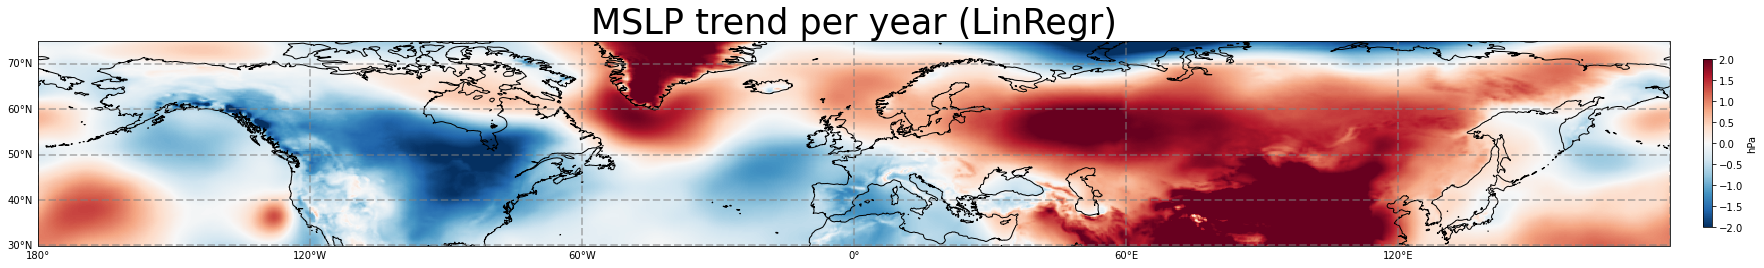

In [40]:
cmap = plt.get_cmap('RdBu_r')

fig, ax = plt.subplots(1,1, figsize=(30,20))
ax1 = plt.subplot(111, projection=ccrs.PlateCarree())

cs = ax1.pcolormesh(mslp_jja_mean["msl"].longitude, mslp_jja_mean["msl"].latitude, reg_coefs,
                 transform=ccrs.PlateCarree(), cmap=cmap, vmin=-2, vmax=2, edgecolors = 'None')

ax1.coastlines()
ax1.set_title(f"MSLP trend per year (LinRegr)", fontsize=35)
ax1.set_xlabel("Longitude")
ax1.set_ylabel("Latitude")

gl = ax1.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                      linewidth=2, color='gray', alpha=0.5, linestyle='--')
gl.xlabels_top = False
gl.ylabels_right = False

fig.colorbar(cs, ax=ax1, fraction=0.005, pad=0.02, label="hPa")

plt.show()

#### what is the mean and std values per grid point?

#### maybe zoom in for a bit on the north atlantic sector 

In [5]:
mslp_NA = mslp["msl"].sel(longitude=mslp["msl"].longitude>-75, method="nearest") 
mslp_NA = mslp_NA.sel(longitude=mslp_NA.longitude<60,method="nearest")
mslp_NA

<xarray.DataArray 'msl' (time: 7728, latitude: 181, longitude: 539)>
[753935952 values with dtype=float32]
Coordinates:
  * time       (time) datetime64[ns] 1940-06-01T11:00:00 ... 2023-08-31T11:00:00
  * longitude  (longitude) float32 -74.75 -74.5 -74.25 ... 59.25 59.5 59.75
  * latitude   (latitude) float32 75.0 74.75 74.5 74.25 ... 30.5 30.25 30.0
Attributes:
    standard_name:  air_pressure_at_mean_sea_level
    long_name:      Mean sea level pressure
    units:          Pa
    cell_methods:   time: mean

calculating mean and std per gridpoint 

In [7]:
mslp_NA_mean = mslp_NA.mean(dim="time")

In [8]:
mslp_NA_std = mslp_NA.std(dim="time")

calculating the lin trend 

In [11]:
mslp_NA_jjamean = mslp_NA.groupby(mslp_NA.time.dt.year).mean(dim="time")
### 
reg_coefs_ = np.empty(mslp_NA_jjamean.shape[1:]) #create empty numpy array to save the lin regr coefs in 

x = mslp_NA_jjamean.year.to_numpy().reshape(-1,1) #get the years 
x = np.arange(0,84,1).reshape(-1,1)

for i, lat in enumerate(mslp_NA_jjamean.latitude): #loop over the gridpoints 
    for j, lon in enumerate(mslp_NA_jjamean.longitude):
        
        y = mslp_NA_jjamean.sel(latitude=lat, longitude=lon) #get the MSLP data 
        reg = LinearRegression().fit(x, y) #fit the regressor
        reg_coefs_[i,j]=reg.coef_[0] #save the coef in the array

### plotting stats

/sw/arch/RHEL8/EB_production/2022/software/Cartopy/0.20.3-foss-2022a/lib/python3.10/site-packages/cartopy/mpl/gridliner.py:451: UserWarning: The .xlabels_top attribute is deprecated. Please use .top_labels to toggle visibility instead.
  warnings.warn('The .xlabels_top attribute is deprecated. Please '
/sw/arch/RHEL8/EB_production/2022/software/Cartopy/0.20.3-foss-2022a/lib/python3.10/site-packages/cartopy/mpl/gridliner.py:487: UserWarning: The .ylabels_right attribute is deprecated. Please use .right_labels to toggle visibility instead.
  warnings.warn('The .ylabels_right attribute is deprecated. Please '
/sw/arch/RHEL8/EB_production/2022/software/Cartopy/0.20.3-foss-2022a/lib/python3.10/site-packages/cartopy/mpl/gridliner.py:451: UserWarning: The .xlabels_top attribute is deprecated. Please use .top_labels to toggle visibility instead.
  warnings.warn('The .xlabels_top attribute is deprecated. Please '
/sw/arch/RHEL8/EB_production/2022/software/Cartopy/0.20.3-foss-2022a/lib/python3.1

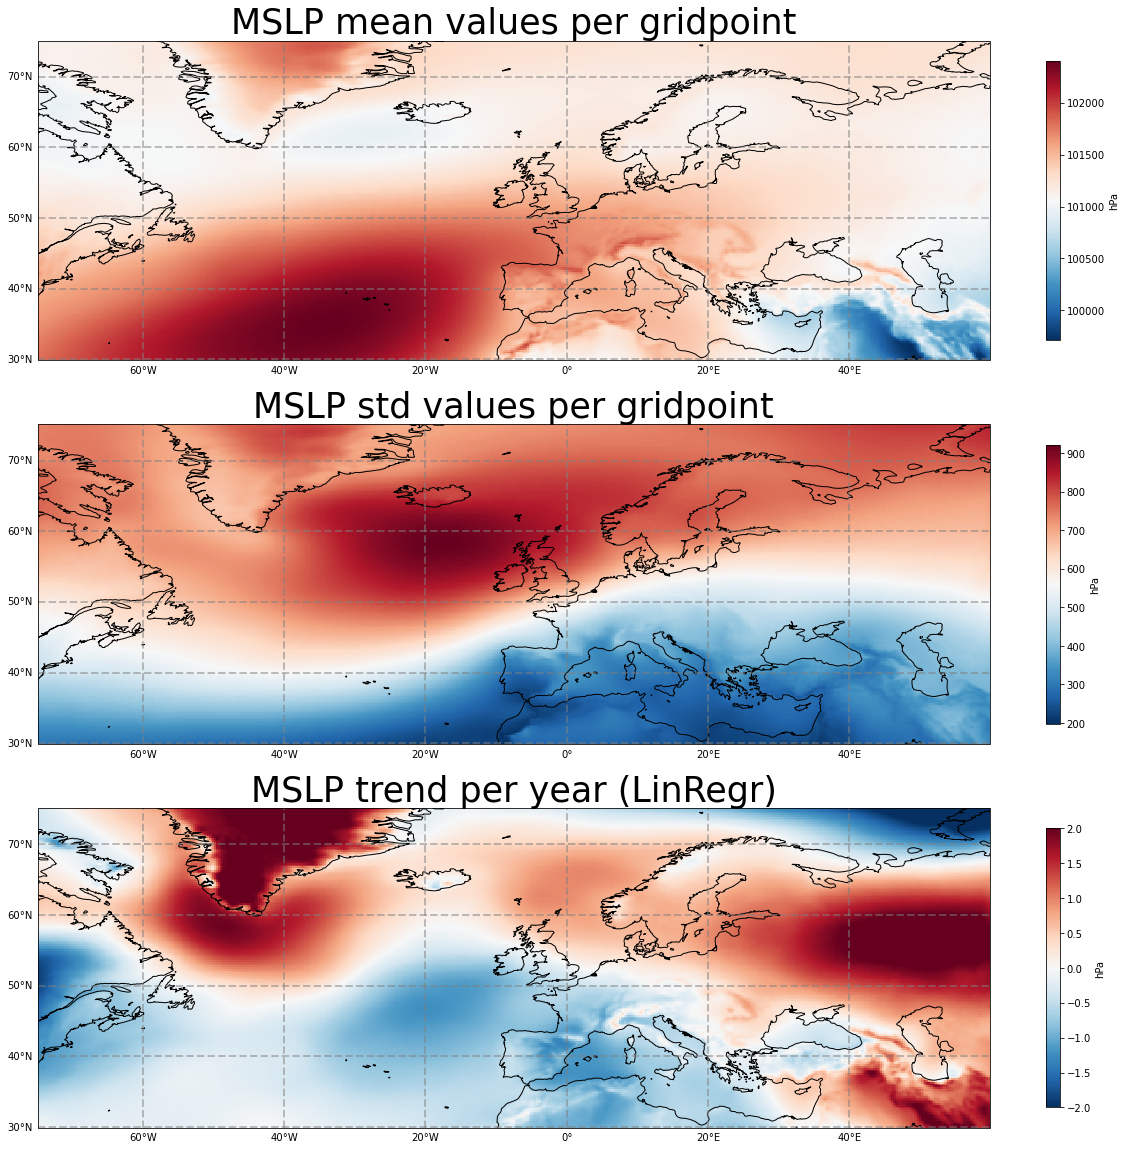

In [13]:
cmap = plt.get_cmap('RdBu_r')

fig, axes = plt.subplots(3,1, figsize=(50,20))

####

ax1 = plt.subplot(311, projection=ccrs.PlateCarree())

cs = ax1.pcolormesh(mslp_NA.longitude, mslp_NA.latitude, mslp_NA_mean,
                 transform=ccrs.PlateCarree(), cmap=cmap, edgecolors = 'None') #vmin=-2, vmax=2, 

ax1.coastlines()
ax1.set_title(f"MSLP mean values per gridpoint", fontsize=35)
ax1.set_xlabel("Longitude")
ax1.set_ylabel("Latitude")

gl = ax1.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                      linewidth=2, color='gray', alpha=0.5, linestyle='--')
gl.xlabels_top = False
gl.ylabels_right = False

fig.colorbar(cs, ax=ax1, fraction=0.005, pad=0.02, label="hPa")

####
ax2 = plt.subplot(312, projection=ccrs.PlateCarree())

cs = ax2.pcolormesh(mslp_NA.longitude, mslp_NA.latitude, mslp_NA_std,
                 transform=ccrs.PlateCarree(), cmap=cmap, edgecolors = 'None') #vmin=-2, vmax=2, 

ax2.coastlines()
ax2.set_title(f"MSLP std values per gridpoint", fontsize=35)
ax2.set_xlabel("Longitude")
ax2.set_ylabel("Latitude")

gl = ax2.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                      linewidth=2, color='gray', alpha=0.5, linestyle='--')
gl.xlabels_top = False
gl.ylabels_right = False

fig.colorbar(cs, ax=ax2, fraction=0.005, pad=0.02, label="hPa")

###

ax3 = plt.subplot(313, projection=ccrs.PlateCarree())

cs = ax3.pcolormesh(mslp_NA_jjamean.longitude, mslp_NA_jjamean.latitude, reg_coefs_,
                 transform=ccrs.PlateCarree(), cmap=cmap, vmin=-2, vmax=2, edgecolors = 'None')

ax3.coastlines()
ax3.set_title(f"MSLP trend per year (LinRegr)", fontsize=35)
ax3.set_xlabel("Longitude")
ax3.set_ylabel("Latitude")

gl = ax3.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                      linewidth=2, color='gray', alpha=0.5, linestyle='--')
gl.xlabels_top = False
gl.ylabels_right = False

fig.colorbar(cs, ax=ax3, fraction=0.005, pad=0.02, label="hPa")

plt.show()

## question is thus how to detrend the mslp

Ik bereken std en mean per grid point, dus als ik per grid point detrend, hoe zien dan de mean en std erna eruit?

In [56]:
mslp_NA_detr = np.empty_like(mslp_NA) #copy dataset
for i, year in enumerate(np.arange(1940,2024,1)):
    year = mslp_NA.sel(time=mslp_NA.time.dt.year==year).to_numpy() 
    detrended = year + (reg_coefs_ * i)
    mslp_NA_detr[i*92:(i+1)*92] = detrended

In [61]:
detrended_mslp_NA_xr = xr.DataArray(
    data=mslp_NA_detr,
    dims=["time", "latitude", "longitude"],
    coords=dict(
        time=mslp_NA.time,
        latitude=mslp_NA.latitude,
        longitude=mslp_NA.longitude,
    ),
    attrs=dict(
        description="detrended MSLP using Lin Regr per grid point",
        units="hPa",
    ),
)

In [69]:
detrended_mslp_NA_xr.to_netcdf(f"{data_path}LinRegrDetrendedperGridpoint_MSLP_era5_NHmidlats_0.25degr_1940_2023_JJA.nc")

In [63]:
mslp_NA_detr_mean = detrended_mslp_NA_xr.mean(dim="time")

In [64]:
mslp_NA_detr_std = detrended_mslp_NA_xr.std(dim="time")

/sw/arch/RHEL8/EB_production/2022/software/Cartopy/0.20.3-foss-2022a/lib/python3.10/site-packages/cartopy/mpl/gridliner.py:451: UserWarning: The .xlabels_top attribute is deprecated. Please use .top_labels to toggle visibility instead.
  warnings.warn('The .xlabels_top attribute is deprecated. Please '
/sw/arch/RHEL8/EB_production/2022/software/Cartopy/0.20.3-foss-2022a/lib/python3.10/site-packages/cartopy/mpl/gridliner.py:487: UserWarning: The .ylabels_right attribute is deprecated. Please use .right_labels to toggle visibility instead.
  warnings.warn('The .ylabels_right attribute is deprecated. Please '
/sw/arch/RHEL8/EB_production/2022/software/Cartopy/0.20.3-foss-2022a/lib/python3.10/site-packages/cartopy/mpl/gridliner.py:451: UserWarning: The .xlabels_top attribute is deprecated. Please use .top_labels to toggle visibility instead.
  warnings.warn('The .xlabels_top attribute is deprecated. Please '
/sw/arch/RHEL8/EB_production/2022/software/Cartopy/0.20.3-foss-2022a/lib/python3.1

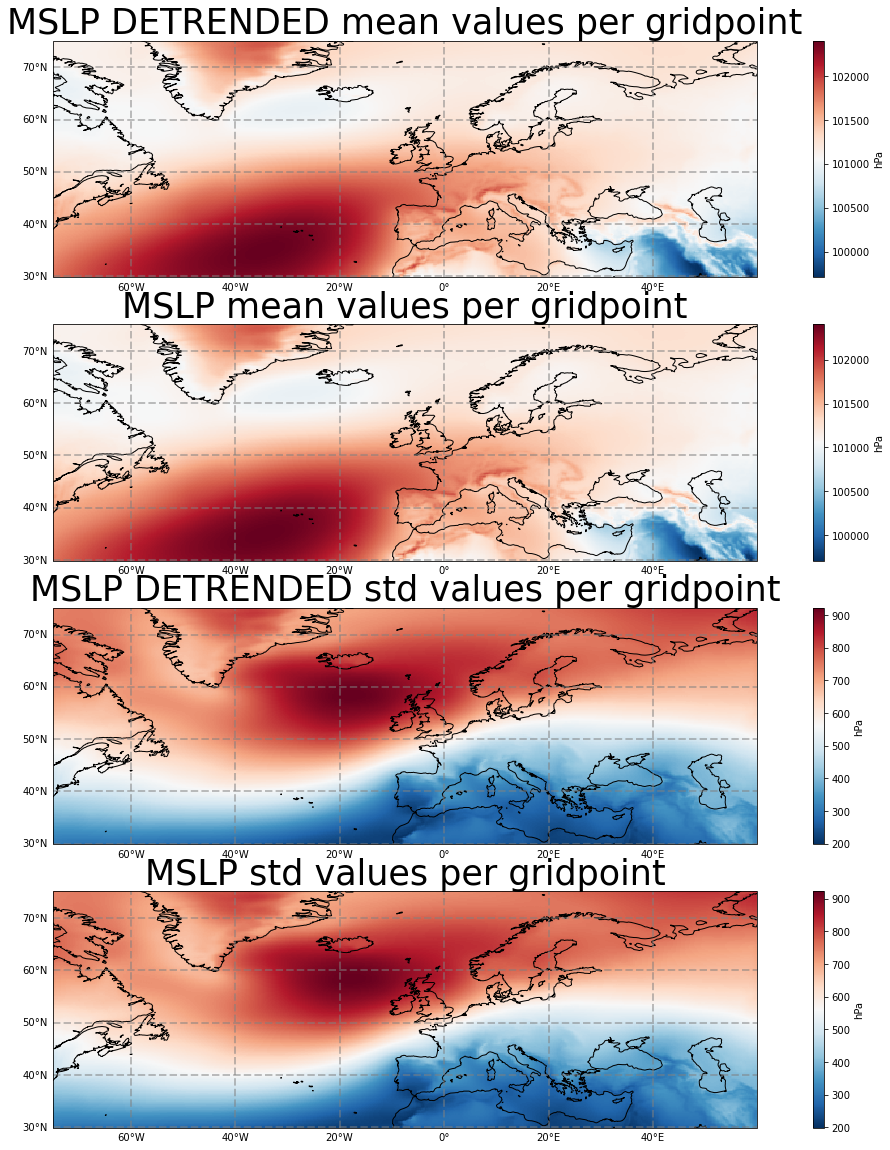

In [65]:
cmap = plt.get_cmap('RdBu_r')

fig, axes = plt.subplots(4,1, figsize=(50,20))

####

ax1 = plt.subplot(411, projection=ccrs.PlateCarree())

cs = ax1.pcolormesh(mslp_NA.longitude, mslp_NA.latitude, mslp_NA_detr_mean,
                 transform=ccrs.PlateCarree(), cmap=cmap, edgecolors = 'None') #vmin=-2, vmax=2, 

ax1.coastlines()
ax1.set_title(f"MSLP DETRENDED mean values per gridpoint", fontsize=35)
ax1.set_xlabel("Longitude")
ax1.set_ylabel("Latitude")

gl = ax1.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                      linewidth=2, color='gray', alpha=0.5, linestyle='--')
gl.xlabels_top = False
gl.ylabels_right = False

fig.colorbar(cs, ax=ax1, fraction=0.005, pad=0.02, label="hPa")

####

ax2 = plt.subplot(412, projection=ccrs.PlateCarree())

cs = ax2.pcolormesh(mslp_NA.longitude, mslp_NA.latitude, mslp_NA_mean,
                 transform=ccrs.PlateCarree(), cmap=cmap, edgecolors = 'None') #vmin=-2, vmax=2, 

ax2.coastlines()
ax2.set_title(f"MSLP mean values per gridpoint", fontsize=35)
ax2.set_xlabel("Longitude")
ax2.set_ylabel("Latitude")

gl = ax2.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                      linewidth=2, color='gray', alpha=0.5, linestyle='--')
gl.xlabels_top = False
gl.ylabels_right = False

fig.colorbar(cs, ax=ax2, fraction=0.005, pad=0.02, label="hPa")


####
ax3 = plt.subplot(413, projection=ccrs.PlateCarree())

cs = ax3.pcolormesh(mslp_NA.longitude, mslp_NA.latitude, mslp_NA_detr_std,
                 transform=ccrs.PlateCarree(), cmap=cmap, edgecolors = 'None') #vmin=-2, vmax=2, 

ax3.coastlines()
ax3.set_title(f"MSLP DETRENDED std values per gridpoint", fontsize=35)
ax3.set_xlabel("Longitude")
ax3.set_ylabel("Latitude")

gl = ax3.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                      linewidth=2, color='gray', alpha=0.5, linestyle='--')
gl.xlabels_top = False
gl.ylabels_right = False

fig.colorbar(cs, ax=ax3, fraction=0.005, pad=0.02, label="hPa")

####
ax4 = plt.subplot(414, projection=ccrs.PlateCarree())

cs = ax4.pcolormesh(mslp_NA.longitude, mslp_NA.latitude, mslp_NA_std,
                 transform=ccrs.PlateCarree(), cmap=cmap, edgecolors = 'None') #vmin=-2, vmax=2, 

ax4.coastlines()
ax4.set_title(f"MSLP std values per gridpoint", fontsize=35)
ax4.set_xlabel("Longitude")
ax4.set_ylabel("Latitude")

gl = ax4.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                      linewidth=2, color='gray', alpha=0.5, linestyle='--')
gl.xlabels_top = False
gl.ylabels_right = False

fig.colorbar(cs, ax=ax4, fraction=0.005, pad=0.02, label="hPa")


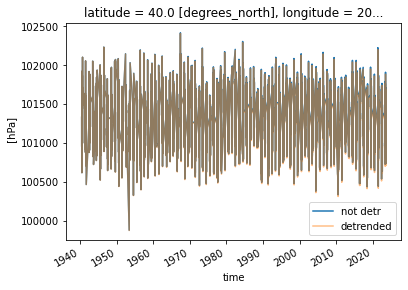

In [67]:
mslp_NA.sel(latitude=40, longitude=20, method="nearest").plot(label="not detr")
detrended_mslp_NA_xr.sel(latitude=40, longitude=20, method="nearest").plot(alpha=0.5, label="detrended")
plt.legend()

/sw/arch/RHEL8/EB_production/2022/software/Cartopy/0.20.3-foss-2022a/lib/python3.10/site-packages/cartopy/mpl/gridliner.py:451: UserWarning: The .xlabels_top attribute is deprecated. Please use .top_labels to toggle visibility instead.
  warnings.warn('The .xlabels_top attribute is deprecated. Please '
/sw/arch/RHEL8/EB_production/2022/software/Cartopy/0.20.3-foss-2022a/lib/python3.10/site-packages/cartopy/mpl/gridliner.py:487: UserWarning: The .ylabels_right attribute is deprecated. Please use .right_labels to toggle visibility instead.
  warnings.warn('The .ylabels_right attribute is deprecated. Please '
/sw/arch/RHEL8/EB_production/2022/software/Cartopy/0.20.3-foss-2022a/lib/python3.10/site-packages/cartopy/mpl/gridliner.py:451: UserWarning: The .xlabels_top attribute is deprecated. Please use .top_labels to toggle visibility instead.
  warnings.warn('The .xlabels_top attribute is deprecated. Please '
/sw/arch/RHEL8/EB_production/2022/software/Cartopy/0.20.3-foss-2022a/lib/python3.1

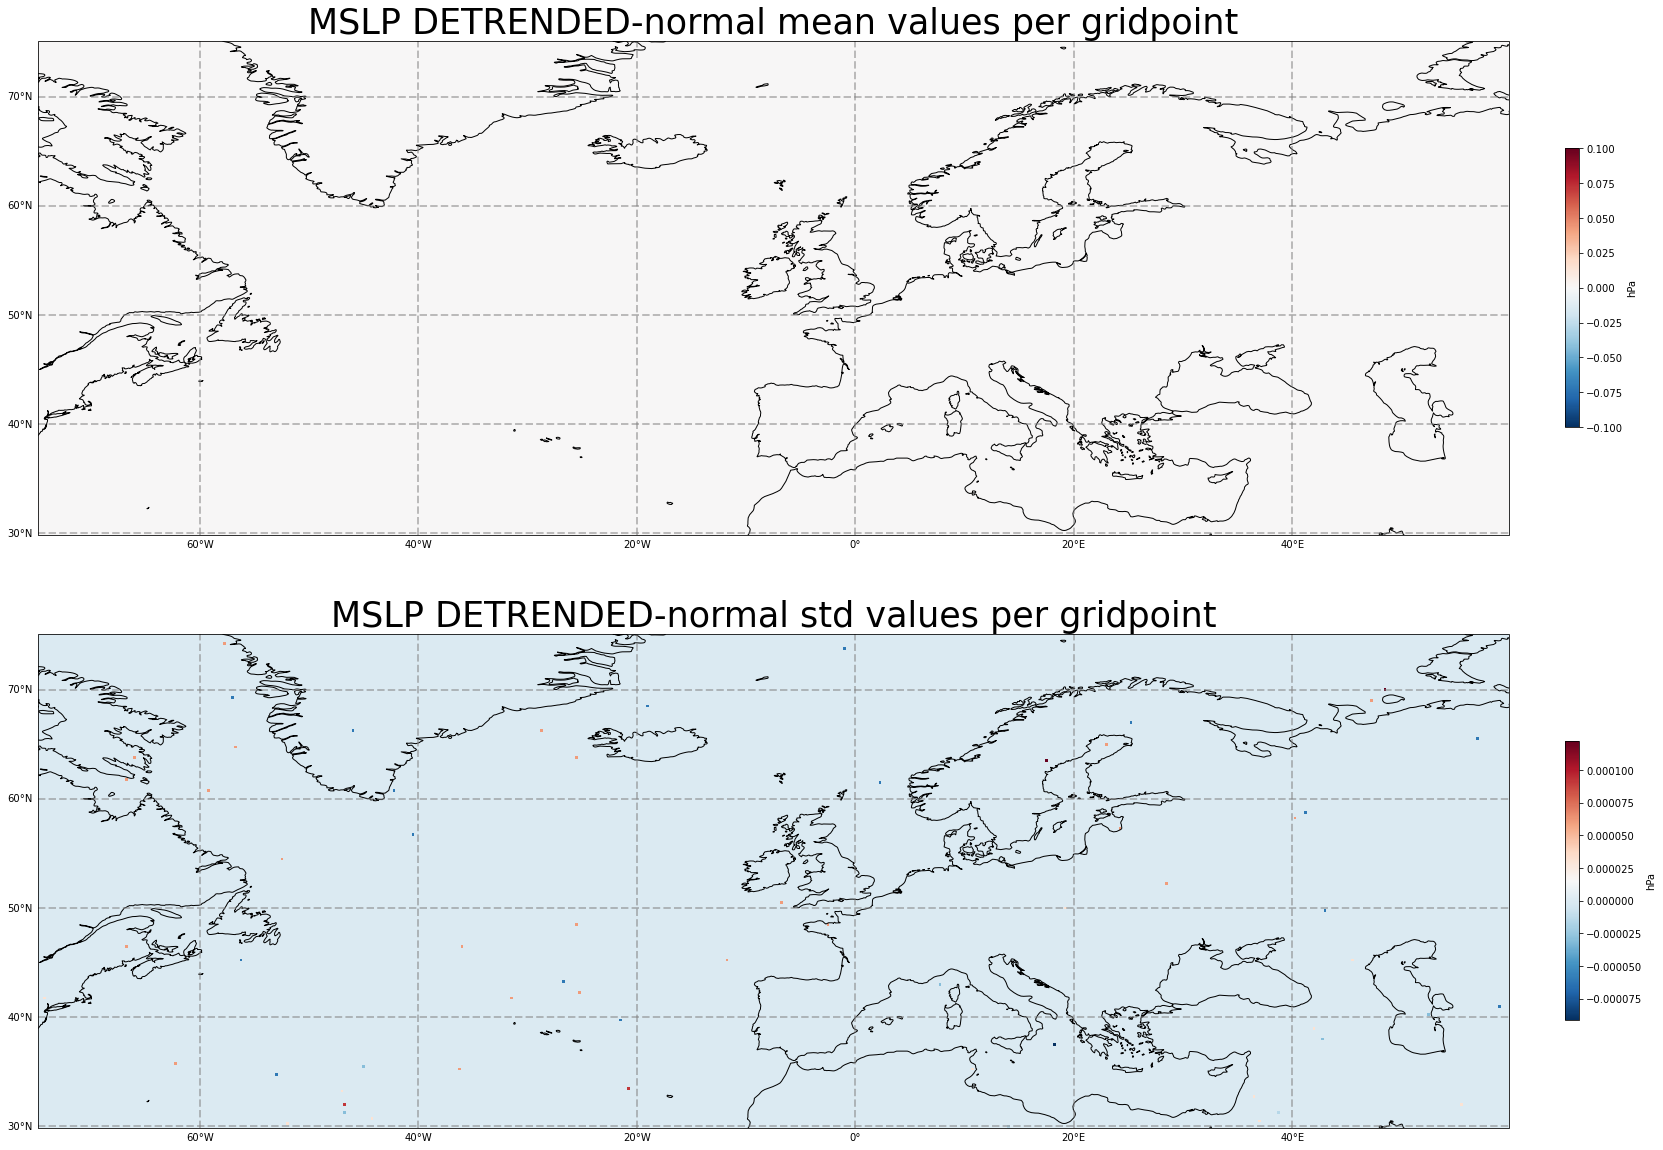

In [68]:
cmap = plt.get_cmap('RdBu_r')

fig, axes = plt.subplots(2,1, figsize=(50,20))

####

ax1 = plt.subplot(211, projection=ccrs.PlateCarree())

cs = ax1.pcolormesh(mslp_NA.longitude, mslp_NA.latitude, mslp_NA_detr_mean - mslp_NA_mean,
                 transform=ccrs.PlateCarree(), cmap=cmap, edgecolors = 'None') #vmin=-2, vmax=2, 

ax1.coastlines()
ax1.set_title(f"MSLP DETRENDED-normal mean values per gridpoint", fontsize=35)
ax1.set_xlabel("Longitude")
ax1.set_ylabel("Latitude")

gl = ax1.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                      linewidth=2, color='gray', alpha=0.5, linestyle='--')
gl.xlabels_top = False
gl.ylabels_right = False

fig.colorbar(cs, ax=ax1, fraction=0.005, pad=0.02, label="hPa")

####

ax2 = plt.subplot(212, projection=ccrs.PlateCarree())

cs = ax2.pcolormesh(mslp_NA.longitude, mslp_NA.latitude, mslp_NA_detr_std - mslp_NA_std,
                 transform=ccrs.PlateCarree(), cmap=cmap, edgecolors = 'None') #vmin=-2, vmax=2, 

ax2.coastlines()
ax2.set_title(f"MSLP DETRENDED-normal std values per gridpoint", fontsize=35)
ax2.set_xlabel("Longitude")
ax2.set_ylabel("Latitude")

gl = ax2.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                      linewidth=2, color='gray', alpha=0.5, linestyle='--')
gl.xlabels_top = False
gl.ylabels_right = False

fig.colorbar(cs, ax=ax2, fraction=0.005, pad=0.02, label="hPa")

### nu nog detrenden met region-wide mean en std 